# hypopy tutorial — unstructured mesh, P-wave arrivals only

This mirrors `hypopy-tutorial.ipynb` step for step, but the velocity model
lives on a **tetrahedral mesh** (`ttcrpy.tmesh.Mesh3d`) rather than a
rectilinear grid.  `hypo.jointHypoVel` takes the grid object and does not care
which kind it is, so the workflow itself is unchanged.

Three things are worth knowing before adapting this to your own mesh.

* **Slowness is defined at the nodes** (`cell_slowness=False`).  The
  regularisation operators the joint inversion needs, `compute_K` and
  `compute_D`, are implemented for node-slowness tetrahedral meshes; a
  cell-slowness mesh raises *"Method computeK should be implemented in
  subclass"*.
* **The mesh must not be perfectly regular.**  Cells are built by splitting
  each cube of a lattice into six tetrahedra (the Freudenthal decomposition),
  then displacing the interior nodes slightly.  Without that displacement
  `compute_K` rejects the mesh — *"Mesh appears poorly conditionned"* — because
  the smoothing operator is singular on a perfectly regular point set.
* **Delaunay on a regular lattice does not work either**: it produces
  degenerate slivers that the eikonal solvers cannot handle.

In [1]:
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
import hypo
from ttcrpy.tmesh import Mesh3d

## Build the tetrahedral mesh

Same domain as the rectilinear tutorial.

In [2]:
def box_tetmesh(x, y, z, jitter=0.0, rng=None):
    """Tetrahedral mesh of a box, six tetrahedra per cube.

    Splitting every cube on a consistent diagonal (the Freudenthal
    decomposition) keeps the tetrahedra well shaped and the faces of
    neighbouring cubes conforming.  `jitter` displaces the interior nodes,
    which is what makes the smoothing operator `compute_K` well conditioned;
    boundary nodes are left in place so the domain keeps its shape.
    """
    nx, ny, nz = len(x), len(y), len(z)
    idx = np.arange(nx * ny * nz).reshape(nx, ny, nz)
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
    nodes = np.column_stack((X.ravel(), Y.ravel(), Z.ravel()))

    if jitter > 0:
        interior = ((nodes[:, 0] > x[0] + 1e-9) & (nodes[:, 0] < x[-1] - 1e-9) &
                    (nodes[:, 1] > y[0] + 1e-9) & (nodes[:, 1] < y[-1] - 1e-9) &
                    (nodes[:, 2] > z[0] + 1e-9) & (nodes[:, 2] < z[-1] - 1e-9))
        nodes[interior] += rng.uniform(-jitter, jitter,
                                       size=(interior.sum(), 3))

    # the eight corners of every cube, indexed as di*4 + dj*2 + dk
    c = [idx[i:i + nx - 1 or None, j:j + ny - 1 or None, k:k + nz - 1 or None]
         for i in (0, 1) for j in (0, 1) for k in (0, 1)]

    quads = ((0, 1, 3, 7), (0, 1, 5, 7), (0, 4, 5, 7),
             (0, 4, 6, 7), (0, 2, 6, 7), (0, 2, 3, 7))
    tet = np.vstack([np.column_stack([c[q].ravel() for q in quad])
                     for quad in quads]).astype(np.int64)
    return nodes, tet


rng = np.random.RandomState(1)

xmin, xmax = 0.090, 0.211
ymin, ymax = 0.080, 0.211
zmin, zmax = 0.0, 0.101
dx = 0.005

x = np.arange(xmin, xmax, dx)
y = np.arange(ymin, ymax, dx)
z = np.arange(zmin, zmax, dx)

nodes, tet = box_tetmesh(x, y, z, jitter=0.10 * dx, rng=rng)
print('{0:d} nodes, {1:d} tetrahedra'.format(nodes.shape[0], tet.shape[0]))

nthreads = 1   # relocating events in parallel currently has an issue

g = Mesh3d(nodes, tet, n_threads=nthreads, cell_slowness=False,
           method='SPM', n_secondary=2)

14175 nodes, 74880 tetrahedra


We need some receivers — the same array as in the rectilinear tutorial.

In [3]:
rcv = np.array([[0.112, 0.115, 0.013],
                [0.111, 0.116, 0.040],
                [0.111, 0.113, 0.090],
                [0.151, 0.117, 0.017],
                [0.180, 0.115, 0.016],
                [0.113, 0.145, 0.011],
                [0.160, 0.150, 0.017],
                [0.185, 0.149, 0.015],
                [0.117, 0.184, 0.011],
                [0.155, 0.192, 0.009],
                [0.198, 0.198, 0.010],
                [0.198, 0.196, 0.040],
                [0.198, 0.193, 0.090]])
ircv = np.arange(rcv.shape[0]).reshape(-1, 1)   # vector of rcv indices
nsta = rcv.shape[0]

Let's create 15 events randomly located in the mesh

In [4]:
np.random.seed(0)   # so the notebook reproduces

nev = 15
src = np.vstack((np.arange(nev),                                    # event ID
                 np.linspace(0., 50., nev) + np.random.randn(nev),  # origin time
                 0.160 + 0.005*np.random.randn(nev),                # x
                 0.140 + 0.005*np.random.randn(nev),                # y
                 0.060 + 0.010*np.random.randn(nev))).T             # z

h_true = src.copy()

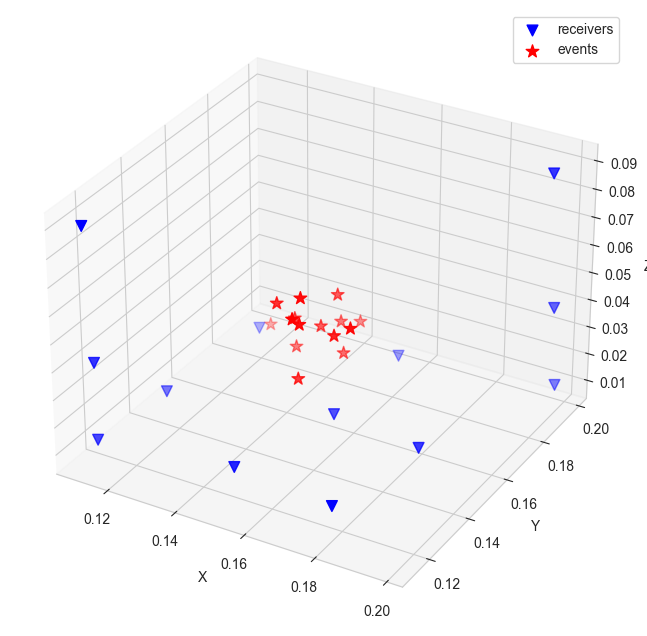

In [5]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d')
ax.scatter(rcv[:, 0], rcv[:, 1], rcv[:, 2], c='b', marker='v', s=60, label='receivers')
ax.scatter(src[:, 2], src[:, 3], src[:, 4], c='r', marker='*', s=90, label='events')
ax.set_xlabel('X'), ax.set_ylabel('Y'), ax.set_zlabel('Z')
ax.legend()
plt.show()

The velocity model is the same small vertical gradient, but assigned **per
tetrahedron** using the cell centroids.

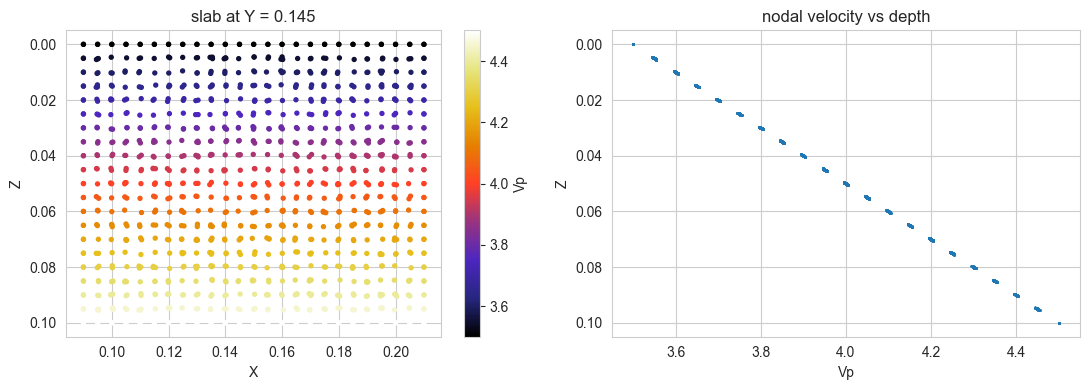

(None, None)

In [6]:
def Vz(z):
    return 4.0 + 10. * (z - 0.050)

Vp = Vz(nodes[:, 2])       # one value per node
slowness = 1. / Vp

sel = np.abs(nodes[:, 1] - 0.145) < dx
plt.figure(figsize=(11, 4))
plt.subplot(121)
plt.scatter(nodes[sel, 0], nodes[sel, 2], c=Vp[sel], s=8, cmap='CMRmap')
plt.gca().invert_yaxis(), plt.xlabel('X'), plt.ylabel('Z')
plt.title('slab at Y = 0.145'), plt.colorbar(label='Vp')
plt.subplot(122)
plt.plot(Vp, nodes[:, 2], '.', ms=1)
plt.gca().invert_yaxis(), plt.xlabel('Vp'), plt.ylabel('Z')
plt.title('nodal velocity vs depth')
plt.tight_layout(), plt.show()

Let's now compute the travel times

In [7]:
src_data = np.kron(src, np.ones((nsta, 1)))   # replicate src-rcv pairs
rcv_data = np.kron(np.ones((nev, 1)), rcv)
ircv_data = np.kron(np.ones((nev, 1)), ircv)

print(src_data.shape)
print(rcv_data.shape)

(195, 5)
(195, 3)


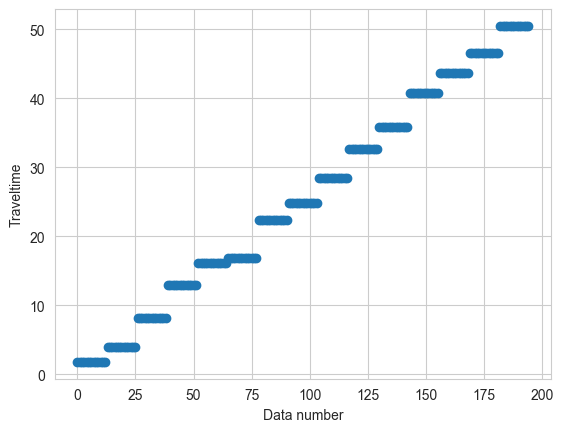

In [8]:
tt = g.raytrace(src_data, rcv_data, slowness)

plt.plot(tt, 'o')
plt.xlabel('Data number')
plt.ylabel('Traveltime')
plt.show()

Add some noise to the data

In [9]:
noise_variance = 1.e-3   # 1 ms
tt += noise_variance*np.random.randn(tt.size)

Combine the event IDs, travel times, and receiver indices

In [10]:
data = np.hstack((src_data[:, 0].reshape((-1, 1)), tt.reshape((-1, 1)), ircv_data))

## Initial hypocenter locations

In [11]:
hinit = np.vstack((np.arange(nev),
                   np.linspace(0., 50., nev),
                   0.150 + 0.0001*np.random.randn(nev),
                   0.150 + 0.0001*np.random.randn(nev),
                   0.050 + 0.0001*np.random.randn(nev))).T

## Velocity data points

Points where the velocity is known, used as a constraint in the inversion.

In [12]:
Vpts = np.array([[Vz(0.001), 0.100, 0.100, 0.001],
                 [Vz(0.001), 0.100, 0.200, 0.001],
                 [Vz(0.001), 0.200, 0.100, 0.001],
                 [Vz(0.001), 0.200, 0.200, 0.001],
                 [Vz(0.011), 0.112, 0.148, 0.011],
                 [Vz(0.005), 0.152, 0.108, 0.005],
                 [Vz(0.075), 0.152, 0.108, 0.075],
                 [Vz(0.011), 0.192, 0.148, 0.011]])

## Calibration shots

Shots at known locations, which constrain the static corrections.

In [13]:
ncal = 5
src_cal = np.vstack((5 + np.arange(ncal),
                     np.zeros(ncal),
                     0.160 + 0.005*np.random.randn(ncal),
                     0.130 + 0.005*np.random.randn(ncal),
                     0.045 + 0.005*np.random.randn(ncal))).T

src_cal = np.kron(src_cal, np.ones((nsta, 1)))
rcv_cal = np.kron(np.ones((ncal, 1)), rcv)
ircv_cal = np.kron(np.ones((ncal, 1)), ircv)

ind = np.ones(rcv_cal.shape[0], dtype=bool)
ind[3] = 0
ind[13] = 0
ind[15] = 0
src_cal = src_cal[ind, :]
rcv_cal = rcv_cal[ind, :]
ircv_cal = ircv_cal[ind, :]

tcal = g.raytrace(src_cal, rcv_cal, slowness)
caldata = np.column_stack((src_cal[:, 0], tcal, ircv_cal, src_cal[:, 2:],
                           np.zeros(tcal.shape)))

## Constant velocity inversion

A first pass with a single velocity, to get the starting locations closer.

In [14]:
Vinit = np.mean(Vpts[:, 0])

hinit2, res = hypo.hypoloc(data, rcv, V=Vinit, hinit=hinit, maxit=15,
                           convh=0.001, verbose=True)


 *** Hypocenter inversion ***

Locating hypocenters no 0
     Converged at iteration 3
Locating hypocenters no 1
     Converged at iteration 2
Locating hypocenters no 2
     Converged at iteration 3
Locating hypocenters no 3
     Converged at iteration 3
Locating hypocenters no 4
     Converged at iteration 3
Locating hypocenters no 5
     Converged at iteration 2
Locating hypocenters no 6
     Converged at iteration 3
Locating hypocenters no 7
     Converged at iteration 3
Locating hypocenters no 8
     Converged at iteration 3
Locating hypocenters no 9
     Converged at iteration 3
Locating hypocenters no 10
     Converged at iteration 3
Locating hypocenters no 11
     Converged at iteration 3
Locating hypocenters no 12
     Converged at iteration 3
Locating hypocenters no 13
     Converged at iteration 3
Locating hypocenters no 14
     Converged at iteration 3

 ** Inversion complete **



     Converged at iteration 3


Locating hypocenters no 1


     Converged at iteration 2


Locating hypocenters no 2


...

Locating hypocenters no 13


     Converged at iteration 3


Locating hypocenters no 14


     Converged at iteration 3



 ** Inversion complete **



Error on hypocenter location after the constant-velocity pass

In [15]:
err_x = hinit2[:, 2:5] - h_true[:, 2:5]
err_t = hinit2[:, 1] - h_true[:, 1]
print('RMS location error : {0:6.4f} km'.format(np.sqrt(np.mean(np.sum(err_x**2, axis=1)))))
print('RMS origin time    : {0:6.4f} s'.format(np.sqrt(np.mean(err_t**2))))

RMS location error : 0.0075 km
RMS origin time    : 0.0016 s


## Joint hypocenter-velocity inversion parameters

In [16]:
Vlim = (3.5, 4.5, 1.0)              # Vpmin, Vpmax, penalty slope
dmax = (0.1, 0.01, 0.01)            # dVp_max, dx_max, dt_max
lagran = (2., 1., 1., 0.1)          # smoothing, penalty, velocity points, wzK

# invert_vel=False: relocate the events in the given model, without
# touching the velocities.  See the note below for why.
par = hypo.InvParams(maxit=3, maxit_hypo=10, conv_hypo=0.001, Vlim=Vlim,
                     dmax=dmax, lagrangians=lagran, invert_vel=False,
                     verbose=True)

The events are relocated in a **fixed** velocity model — here the true one, so
that the relocation is judged on its own rather than on a velocity error.

In [17]:
# the model the events are relocated in: the true one, at the mesh nodes
slowness_reloc = slowness.copy()

## Joint hypocenter-velocity inversion

In [18]:
h, V, sc, res = hypo.jointHypoVel(par, g, data, rcv, slowness_reloc, hinit2,
                                  caldata=caldata, Vpts=Vpts)


 *** Joint hypocenter-velocity inversion ***


Starting iterations
Iteration 1 - Relocating events
  Updating event ID 0 (1/15)
    Updating all hypocenter params - converged at iteration 3
  Updating event ID 1 (2/15)
    Updating all hypocenter params - converged at iteration 2
  Updating event ID 2 (3/15)
    Updating all hypocenter params - converged at iteration 2
  Updating event ID 3 (4/15)
    Updating all hypocenter params - converged at iteration 2
  Updating event ID 4 (5/15)
    Updating all hypocenter params - converged at iteration 2
  Updating event ID 5 (6/15)
    Updating all hypocenter params - converged at iteration 2
  Updating event ID 6 (7/15)
    Updating all hypocenter params - converged at iteration 2
  Updating event ID 7 (8/15)
    Updating all hypocenter params - converged at iteration 2
  Updating event ID 8 (9/15)
    Updating all hypocenter params - converged at iteration 2
  Updating event ID 9 (10/15)
    Updating all hypocenter params - converged at i

  Updating event ID 0 (1/15)


    Updating all hypocenter params

 - converged at iteration 3


  Updating event ID 1 (2/15)


...

 - converged at iteration 1


  Updating event ID 14 (15/15)


    Updating all hypocenter params

 - converged at iteration 1



 ** Inversion complete **



## Results

In [19]:
err_xc = h[:, 2:5] - h_true[:, 2:5]
err_tc = h[:, 1] - h_true[:, 1]

print('constant velocity : RMS location {0:6.4f} km, origin time {1:6.4f} s'.format(
    np.sqrt(np.mean(np.sum(err_x**2, axis=1))), np.sqrt(np.mean(err_t**2))))
print('mesh relocation   : RMS location {0:6.4f} km, origin time {1:6.4f} s'.format(
    np.sqrt(np.mean(np.sum(err_xc**2, axis=1))), np.sqrt(np.mean(err_tc**2))))

constant velocity : RMS location 0.0075 km, origin time 0.0016 s
mesh relocation   : RMS location 0.0045 km, origin time 0.0004 s


Locations before and after relocating in the mesh model.

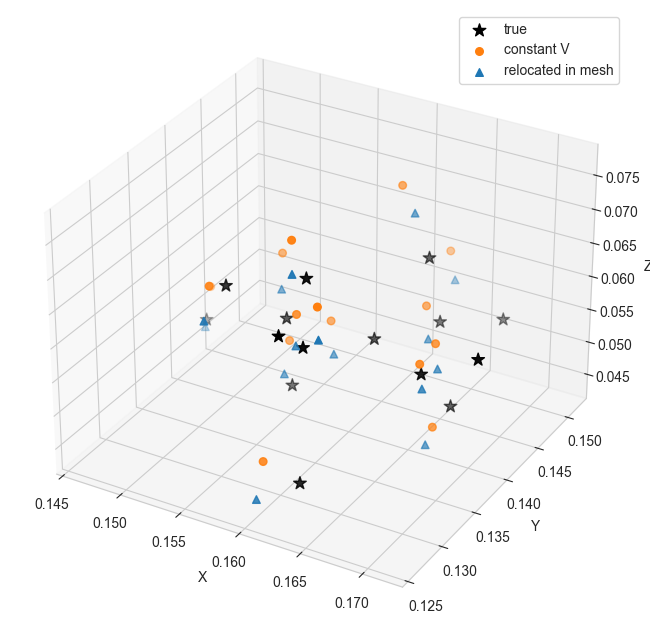

In [20]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d')
ax.scatter(h_true[:, 2], h_true[:, 3], h_true[:, 4], c='k', marker='*', s=90, label='true')
ax.scatter(hinit2[:, 2], hinit2[:, 3], hinit2[:, 4], c='C1', marker='o', s=30, label='constant V')
ax.scatter(h[:, 2], h[:, 3], h[:, 4], c='C0', marker='^', s=30, label='relocated in mesh')
ax.set_xlabel('X'), ax.set_ylabel('Y'), ax.set_zlabel('Z')
ax.legend()
plt.show()

Station corrections

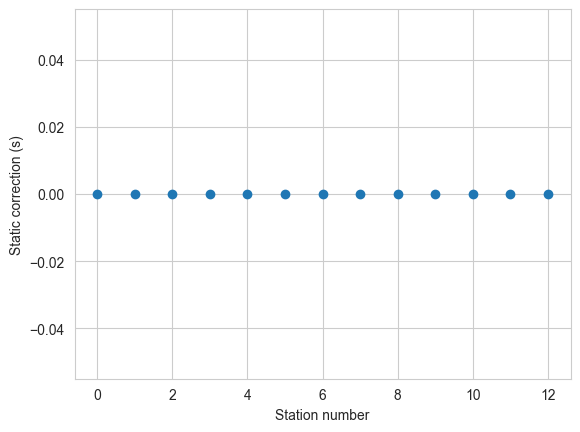

In [21]:
plt.figure()          # the previous cell left a 3-D axes current
plt.plot(sc, 'o')
plt.xlabel('Station number')
plt.ylabel('Static correction (s)')
plt.show()

## Why the velocity inversion is not shown here

`hypo.jointHypoVel` with `invert_vel=True` needs both the sensitivity matrix
**L** (`raytrace(..., compute_L=True)`) and the regularisation operators **K**
and **D**.  On tetrahedral meshes those are implemented for different slowness
types, and no single configuration provides all of them:

| slowness | `raytrace`+L | `compute_K` | `compute_D` | `compute_H` |
|---|---|---|---|---|
| cell (`Grid3Duc`) | yes | no | no | yes |
| node (`Grid3Dun`) | no | yes | yes | yes |

So the joint hypocenter-velocity inversion currently runs on rectilinear grids
only — that is what `hypopy-tutorial.ipynb` shows.  Everything else in the
workflow works on a mesh, including the relocation above, whose Jacobian comes
from `compute_H`.

Closing that gap means implementing `computeK`/`computeD` for `Grid3Duc`, or
the `compute_L` raytrace variants for `Grid3Dun`.